In [1]:
import os, argparse, typing
os.chdir("../")

import numpy as np
import pandas as pd
import scanpy as sc
import torch 
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from functools import partial
import pytorch_lightning as pl
from pytorch_lightning import callbacks 
from pytorch_lightning import loggers as pl_loggers

from PINN import models as models
from PINN import reader 
from PINN import functions as fns

In [4]:
import matplotlib.pyplot as plt
from PINN import pl
from importlib import reload

In [5]:
reload(reader)

<module 'PINN.reader' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/reader.py'>

In [2]:
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [195]:
n_grid = 50
train_DS =  reader.Simple_DS(n_timepoint = 3, AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid,  nearby_cellstate=2, 
                                    collocation_points=300, n_repeat=2)

# different resolution 

n_grid = 30
train_DS_30 = reader.Simple_DS(n_timepoint = 3, AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid,  nearby_cellstate=2, 
                                    collocation_points=300, n_repeat=2)

# Plot

In [163]:
def load_model(ckptvx):
    
    model_vx = models.MLP(lr=1e-4,channels=[3,32,32,1], activation_fn='Tanh')
    ckpt = torch.load(ckptvx)
    model_vx.load_state_dict(ckpt['state_dict'])
    return model_vx

In [179]:
def pred(modelvx, train_DS, device= 'cuda:7'):

    relu_f = nn.ReLU()
    modelvx = modelvx.to(device)
    
    with torch.no_grad():
        u_pred_b = modelvx(train_DS.s.to(device), train_DS.t_b.to(device))
        u_pred_b = relu_f(u_pred_b)
        
    
    u_pred_b = u_pred_b.cpu()
    u_b = train_DS.u_b.cpu()

    return u_b, u_pred_b

# Version 0

In [49]:
model_v0 = models.MLP(lr=1e-4,channels=[3,32,32,1], activation_fn='Tanh')
ckpt = torch.load("logs/Simple_DS_MLP/lightning_logs/version_0/checkpoints/epoch=136-total_loss=0.00052525.ckpt")
model_v0.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

(<Figure size 900x500 with 6 Axes>,
 array([[<Axes: title={'center': 'Day 3\n\nobserved density'}, xlabel='Actnb', ylabel='Kcnn4'>,
         <Axes: title={'center': 'Day 7\n\nobserved density'}, xlabel='Actnb', ylabel='Kcnn4'>,
         <Axes: title={'center': 'Day 12\n\nobserved density'}, xlabel='Actnb', ylabel='Kcnn4'>],
        [<Axes: title={'center': 'predicted density'}, xlabel='Actnb', ylabel='Kcnn4'>,
         <Axes: title={'center': 'predicted density'}, xlabel='Actnb', ylabel='Kcnn4'>,
         <Axes: title={'center': 'predicted density'}, xlabel='Actnb', ylabel='Kcnn4'>]],
       dtype=object))

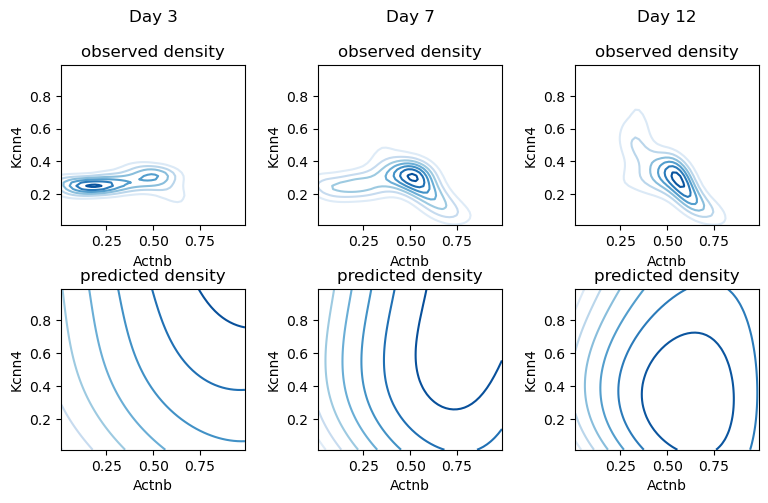

In [50]:
u_b , u_pred_b = pred(model_v0, train_DS)

u_b = u_b.reshape(3, -1)
u_pred_b = u_pred_b.reshape(3, -1)

pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS, cellstate_1='Actnb', cellstate_2='Kcnn4')

# version 1

In [125]:
model = models.MLP(lr=1e-4,channels=[3,32,32,1], activation_fn='Tanh')
ckpt = torch.load("logs/Simple_DS_MLP/lightning_logs/version_1/checkpoints/epoch=299-total_loss=0.00026219.ckpt")
model.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

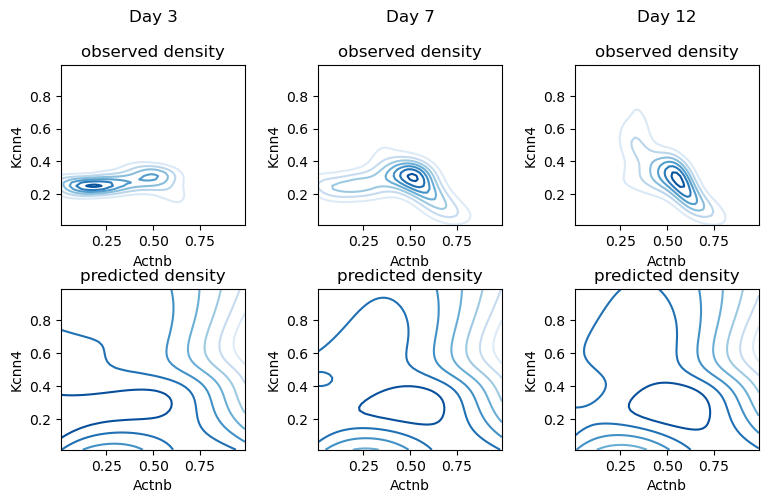

In [126]:
device = 'cuda:7'
model = model.to(device)
with torch.no_grad():
    u_pred_b = model(train_DS.s.to(device), train_DS.t_b.to(device))

u_pred_b = u_pred_b.cpu()
u_b = train_DS.u_b.cpu()

u_b = u_b.reshape(3, -1)
u_pred_b = u_pred_b.reshape(3, -1)
pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS, cellstate_1='Actnb', cellstate_2='Kcnn4');

In [130]:
ckpt = torch.load("logs/Simple_DS_MLP/lightning_logs/version_1/checkpoints/epoch=299-total_loss=0.00026219.ckpt")
print(ckpt.keys())
ckpt['hparams_name'] = ckptv2['hparams_name'] 
ckpt['hyper_parameters']  =ckptv2['hyper_parameters'] 
print(ckpt.keys())
torch.save(ckpt, "logs/Simple_DS_MLP/lightning_logs/version_1/checkpoints/epoch=299-total_loss=0.00026219_plx.ckpt")

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers'])
dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])


In [133]:
ckpt_295 = torch.load("logs/Simple_DS_MLP/lightning_logs/version_1/checkpoints/epoch=295-total_loss=0.00026158.ckpt")

In [135]:
ckpt_295['hparams_name'] = ckptv2['hparams_name'] 
ckpt_295['hyper_parameters']  =ckptv2['hyper_parameters'] 

In [136]:
torch.save(ckpt_295, "logs/Simple_DS_MLP/lightning_logs/version_1/checkpoints/epoch=295-total_loss=0.00026158_plx.ckpt")

tensor(-0.0581) tensor(0.0195)


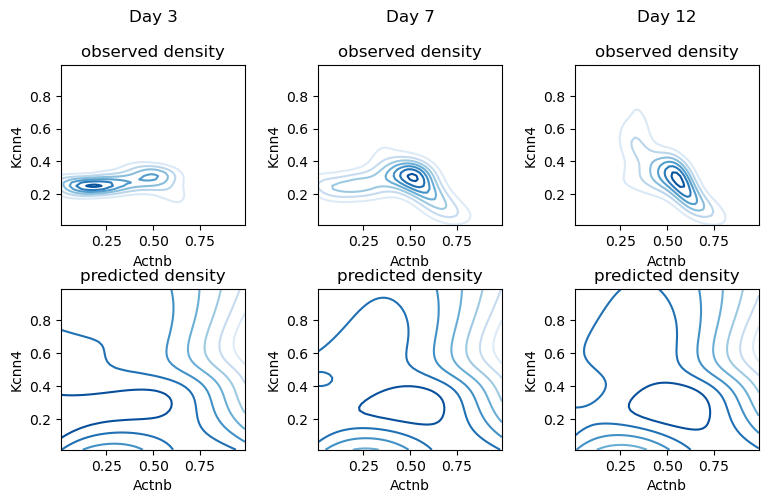

In [153]:
#?
# model_v1 = models.MLP.load_from_checkpoint("logs/Simple_DS_MLP/lightning_logs/version_1/checkpoints/epoch=295-total_loss=0.00026158_plx.ckpt") 

model_v1 = models.MLP(lr=1e-4,channels=[3,32,32,1], activation_fn='Tanh')
ckpt = torch.load("logs/Simple_DS_MLP/lightning_logs/version_1/checkpoints/epoch=299-total_loss=0.00026219.ckpt")
model_v1.load_state_dict(ckpt['state_dict'])

device = 'cuda:7'
model_v1 = model_v1.to(device)
with torch.no_grad():
    u_pred_b = model_v1(train_DS.s.to(device), train_DS.t_b.to(device))

u_pred_b = u_pred_b.cpu()
u_b = train_DS.u_b.cpu()

print(u_pred_b.min(), u_pred_b.max())

u_b = u_b.reshape(3, -1)
u_pred_b = u_pred_b.reshape(3, -1)

pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS, cellstate_1='Actnb', cellstate_2='Kcnn4');

# version 2

In [191]:
ckpt_v2 = "logs/Simple_DS_MLP/lightning_logs/version_2/checkpoints/epoch=2076-total_loss=0.00001744.ckpt"
model_v2 = load_model(ckpt_v2)
# (lr=1e-4,channels=[3,32,32,1], activation_fn='Tanh')

In [192]:
from importlib import reload

In [203]:
reload(pl)

<module 'PINN.pl' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/pl.py'>

tensor(0.) tensor(0.0250)


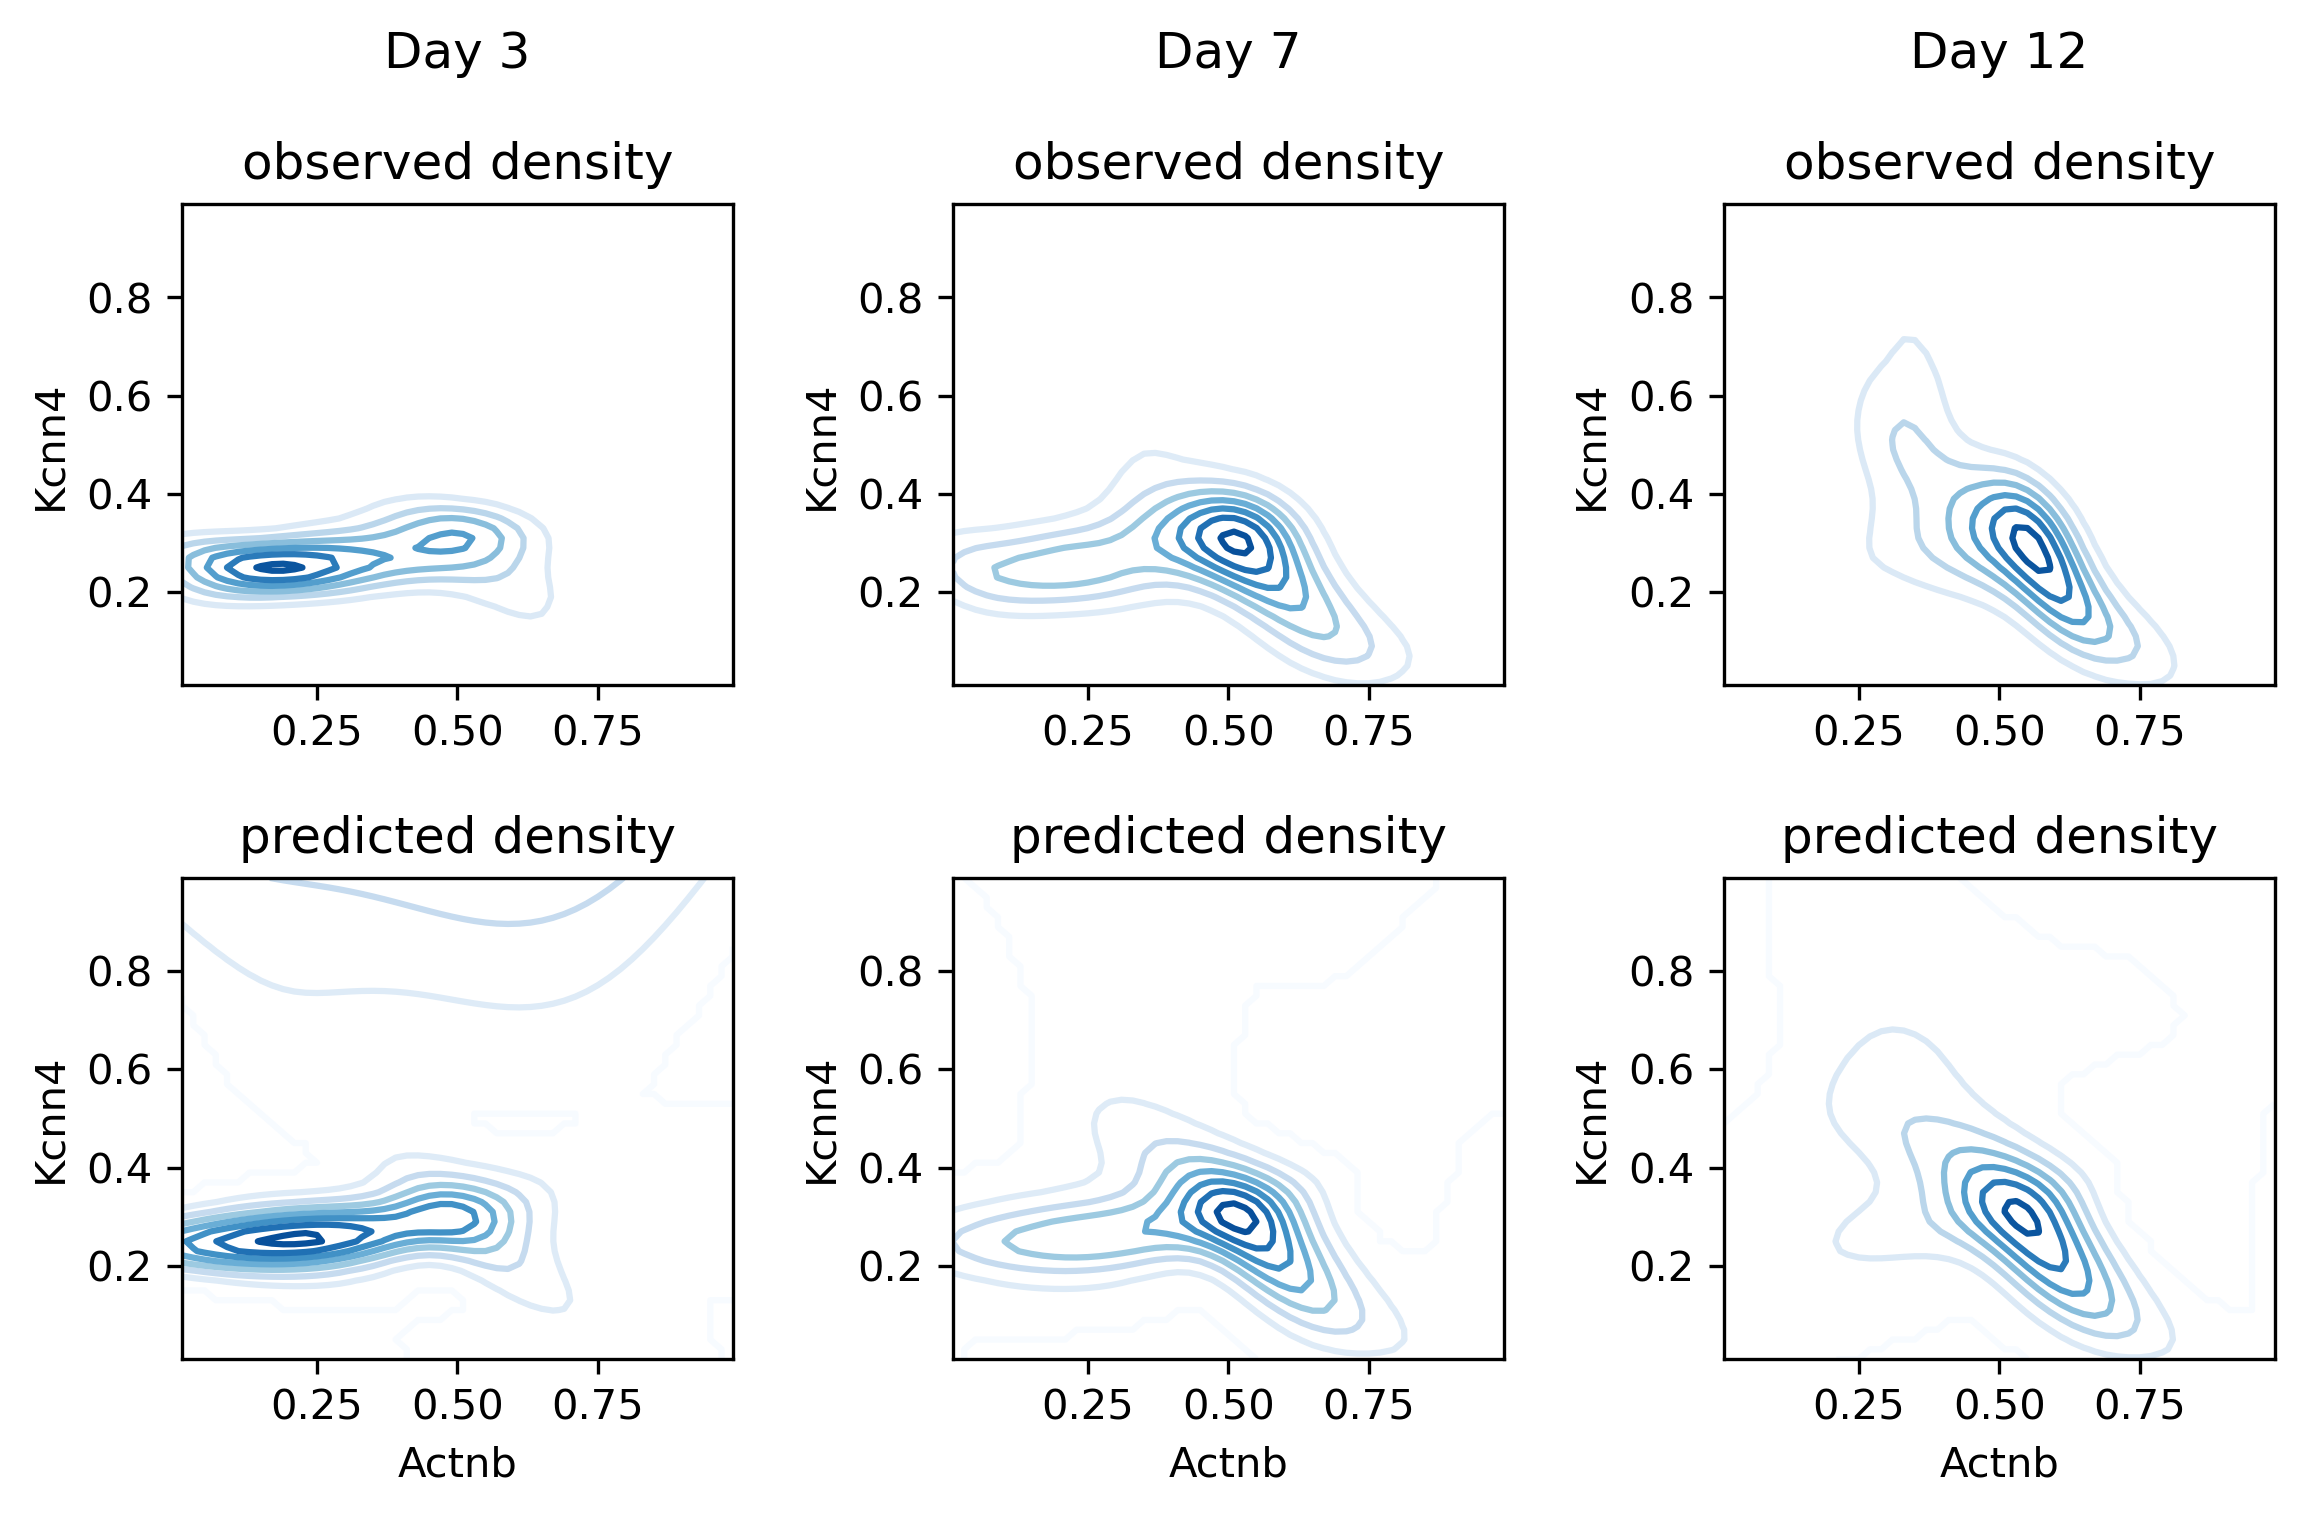

In [204]:
u_b , u_pred_b = pred(model_v2, train_DS)

print(u_pred_b.min(), u_pred_b.max())

u_b = u_b.reshape(3, -1)
u_pred_b = u_pred_b.reshape(3, -1)

pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS, cellstate_1='Actnb', cellstate_2='Kcnn4', fig_kws={'dpi':300});

# Version 3

In [164]:
ckpt_v3 = "logs/Simple_DS_MLP/lightning_logs/version_3/checkpoints/epoch=133-total_loss=0.00016948 copy.ckpt"
model_v3 = load_model(ckpt_v3)

tensor(-0.0518) tensor(0.0157)


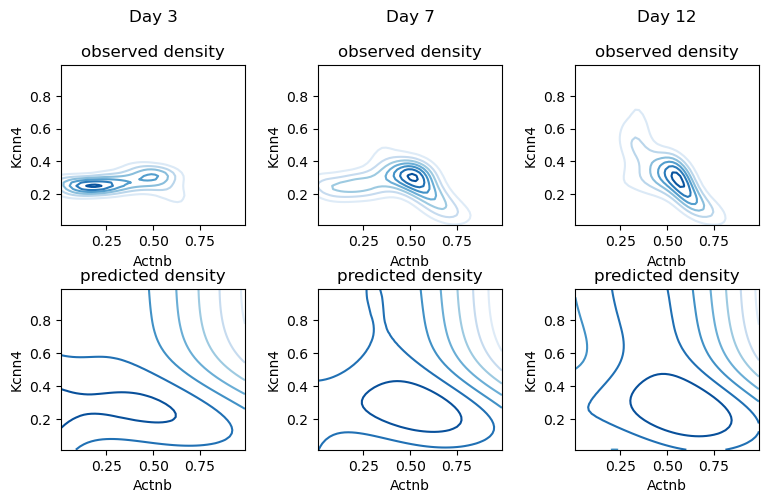

In [165]:
u_b , u_pred_b = pred(model_v3, train_DS)
print(u_pred_b.min(), u_pred_b.max())

u_b = u_b.reshape(3, -1)
u_pred_b = u_pred_b.reshape(3, -1)

pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS, cellstate_1='Actnb', cellstate_2='Kcnn4');

# Verion 4

In [168]:
ckpt_v4 = "logs/Simple_DS_MLP/lightning_logs/version_4/checkpoints/epoch=149-total_loss=0.00012036 copy.ckpt"
model_v4 = load_model(ckpt_v4)

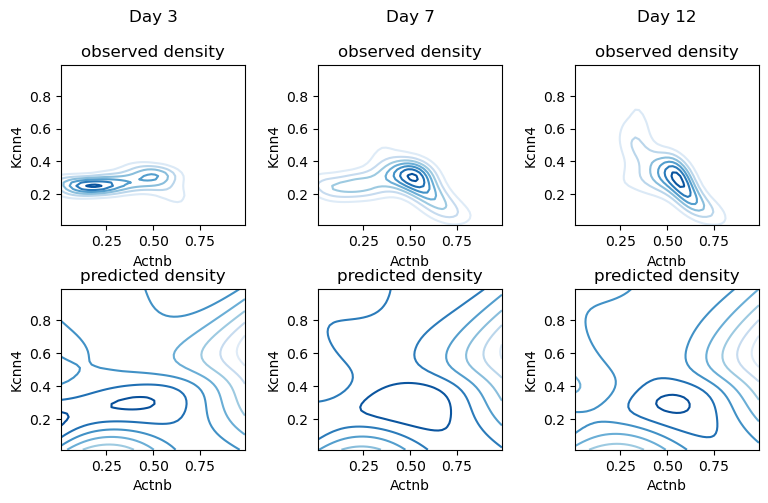

In [170]:
u_b , u_pred_b = pred(model_v4, train_DS)

u_b = u_b.reshape(3, -1)
u_pred_b = u_pred_b.reshape(3, -1)

pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS, cellstate_1='Actnb', cellstate_2='Kcnn4');

# Verion 5

In [160]:
ckpt_v5 = "logs/Simple_DS_MLP/lightning_logs/version_5/checkpoints/epoch=398-total_loss=0.00054596.ckpt"
ckpt_v5 = "logs/Simple_DS_MLP/lightning_logs/version_5/checkpoints/epoch=462-total_loss=0.00049679.ckpt"
# model_v5 = models.MLP.load_from_checkpoint(ckpt_v5)

model_v5 = models.MLP(lr=1e-4,channels=[3,32,32,1], activation_fn='Tanh')
ckpt = torch.load(ckpt_v5)
model_v5.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

(tensor(8.7966), tensor(8.8491))

tensor(-0.1566) tensor(0.0670)


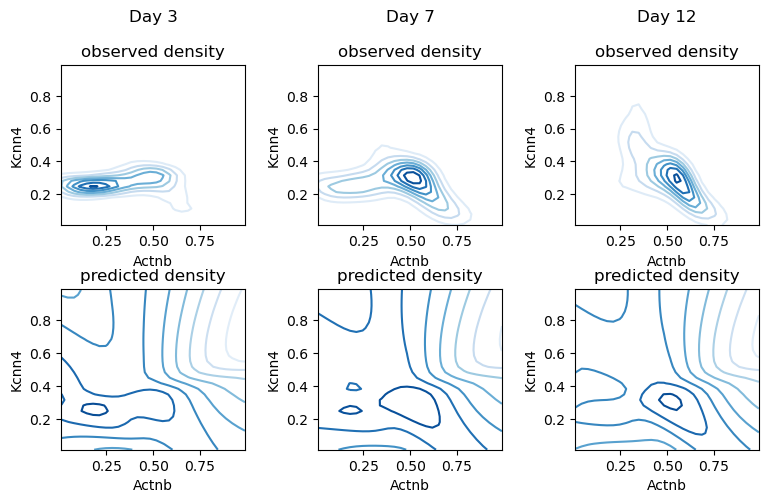

In [161]:
u_b , u_pred_b = pred(model_v5, train_DS_30)

u_b = u_b.reshape(3, -1)
u_pred_b = u_pred_b.reshape(3, -1)

print(u_pred_b.min(), u_pred_b.max())

pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS_30, cellstate_1='Actnb', cellstate_2='Kcnn4');

# Version 6

In [172]:
ckpt_v6 = "logs/Simple_DS_MLP/lightning_logs/version_7/checkpoints/epoch=5-total_loss=0.00017666.ckpt"
model_v6 = load_model(ckpt_v6)

tensor(1.0000e-30) tensor(0.0257)
tensor(-0.0075) tensor(0.0040)


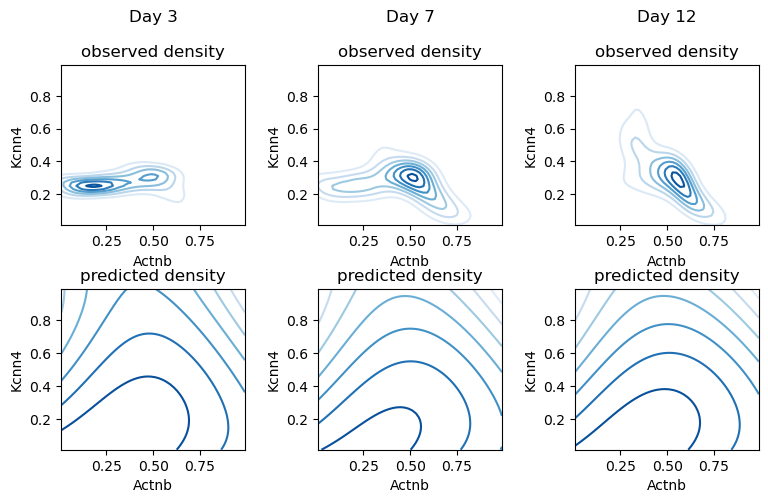

In [173]:
# u_b , u_pred_b = pred(model_v6, train_DS)

# u_b = u_b.reshape(3, -1)
# u_pred_b = u_pred_b.reshape(3, -1)

device = 'cuda:7'
model_v6 = model_v6.to(device)
with torch.no_grad():
    u_pred_b = model_v6(train_DS.s.to(device), train_DS.t_b.to(device))

u_pred_b = u_pred_b.cpu()
u_b = train_DS.u_b.cpu()

u_b = u_b.reshape(3, -1)
u_pred_b = u_pred_b.reshape(3, -1)

print(u_b.min(), u_b.max())
print(u_pred_b.min(), u_pred_b.max())

pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS, cellstate_1='Actnb', cellstate_2='Kcnn4');

# version 7

In [187]:
n_grid = 50

n_timepoint = 5
train_DS_n5 =  reader.Simple_DS(n_timepoint = n_timepoint, AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid,  nearby_cellstate=2, 
                                    collocation_points=300, n_repeat=2)

In [209]:
ckpt_v7 = "logs/Simple_DS_MLP/lightning_logs/version_7/checkpoints/epoch=892-total_loss=0.00007176.ckpt"
model_v7 = load_model(ckpt_v7)

In [211]:
reload(pl)

<module 'PINN.pl' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/pl.py'>

tensor(0.) tensor(0.0309)


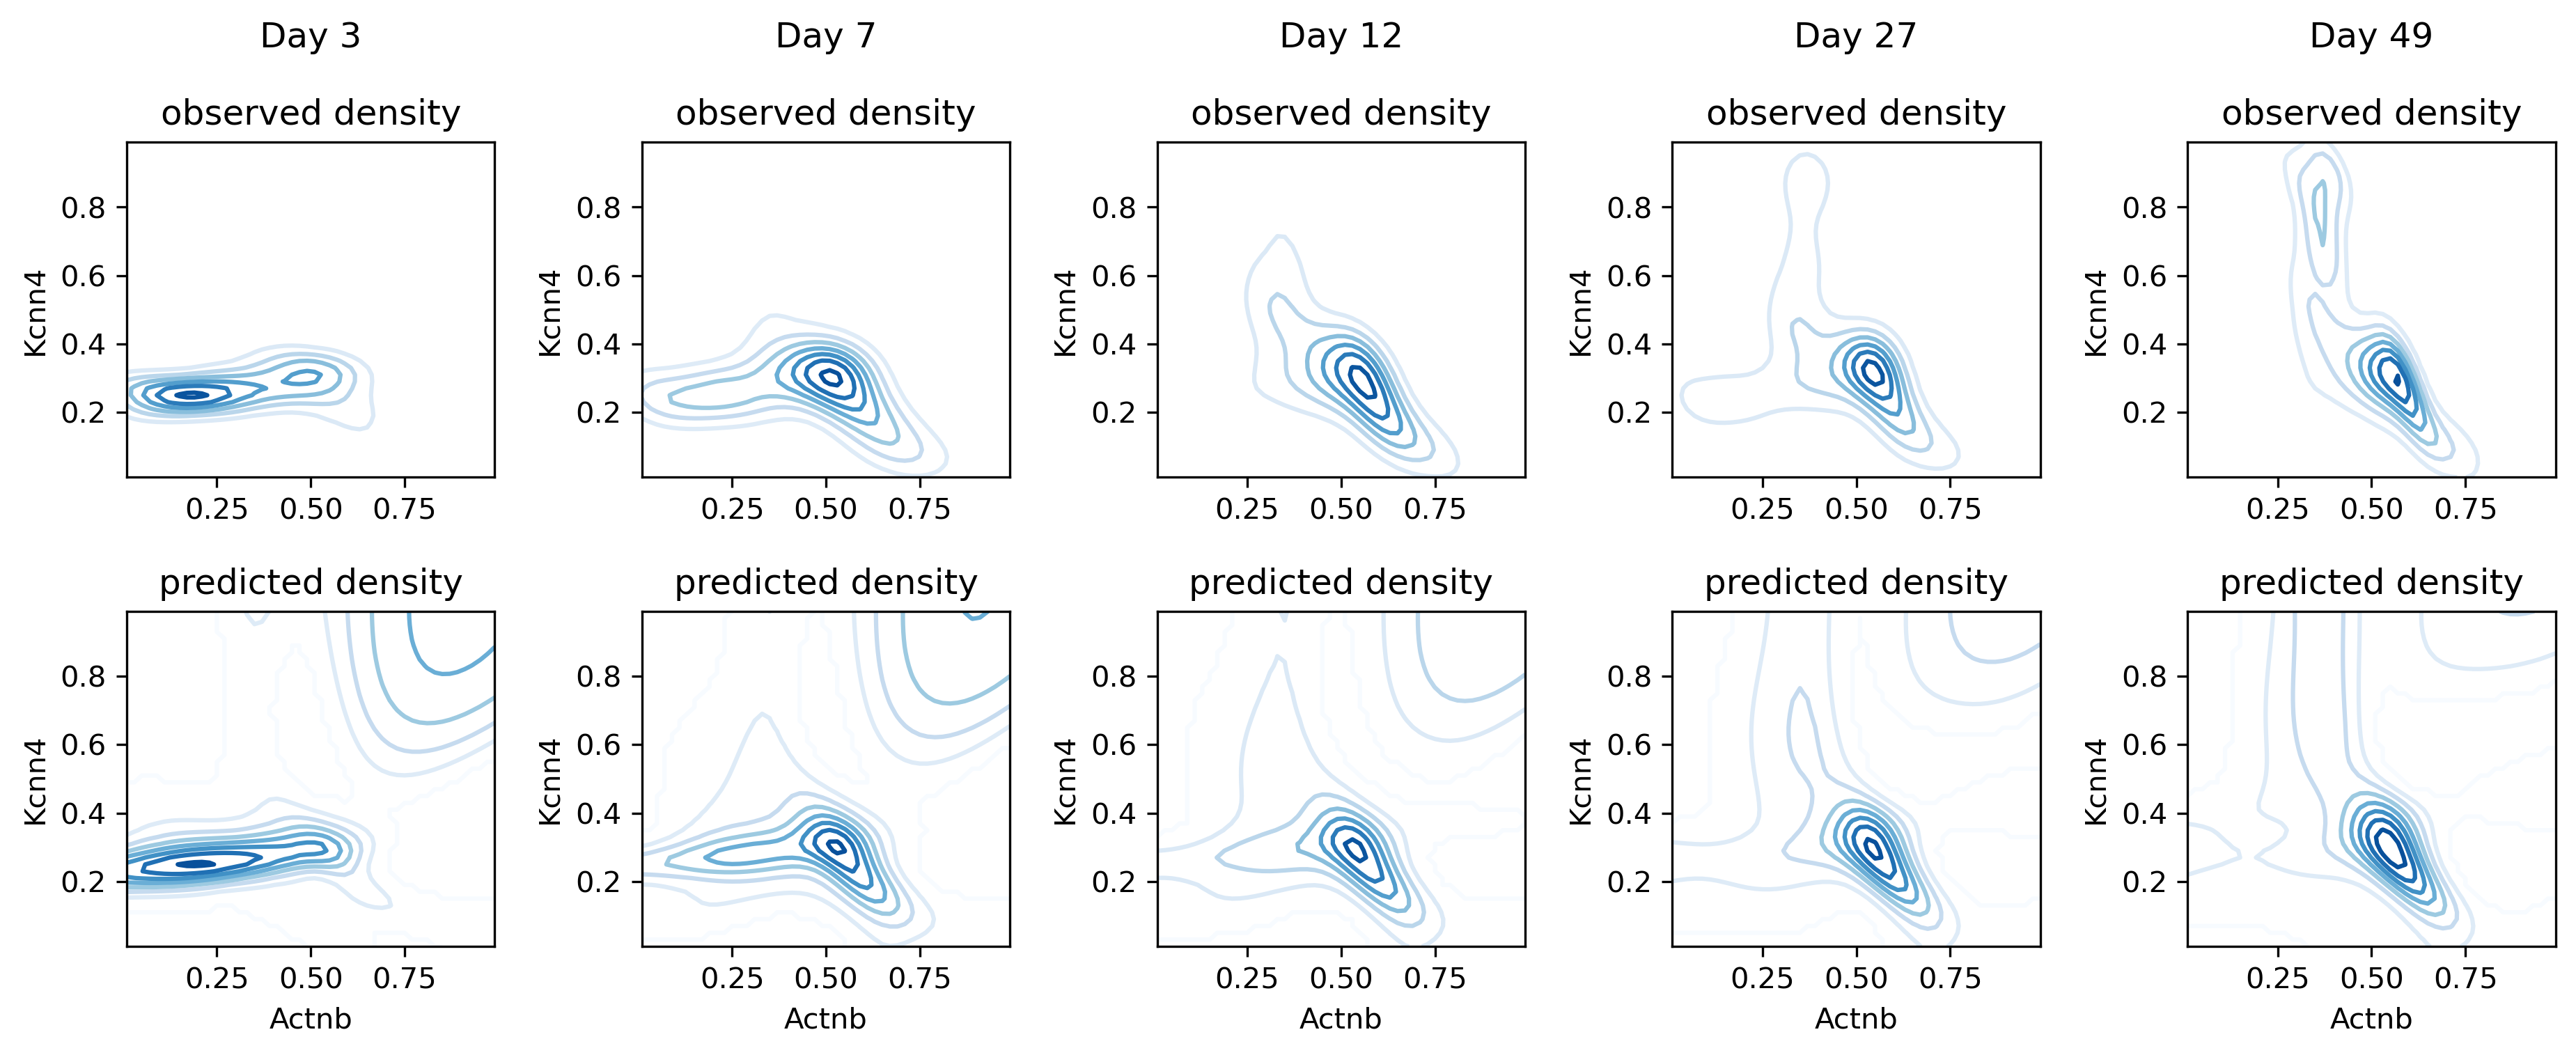

In [213]:
u_b , u_pred_b = pred(model_v7, train_DS_n5)
print(u_pred_b.min(), u_pred_b.max())

u_b = u_b.reshape(n_timepoint, -1)
u_pred_b = u_pred_b.reshape(n_timepoint, -1)

pl.meshgrid_density_by_time(u_b, u_pred_b, train_DS_n5, cellstate_1='Actnb', cellstate_2='Kcnn4' , fig_kws={'dpi':300});

In [216]:
train_DS_n5.T_b

array([0.19636621, 0.34781243, 0.44415279])

In [222]:
continous_t = np.log(np.arange(3,50)) / np.log(269)

In [227]:
s_t = train_DS_n5.s[:2500]

In [230]:
device = model_v7.device

u_pred_cont = []


with torch.no_grad():
    for i, tt_b in enumerate(continous_t):
        
        t = torch.full(size=(2500,1), fill_value=tt_b).float().to(device)
        upred = model_v7(s_t.float().to(device), t)
        
        u_pred_cont.append(upred.cpu().numpy())

In [231]:
u_pred_immpute = np.array(u_pred_cont)

In [232]:
u_pred_immpute.shape

(47, 2500)

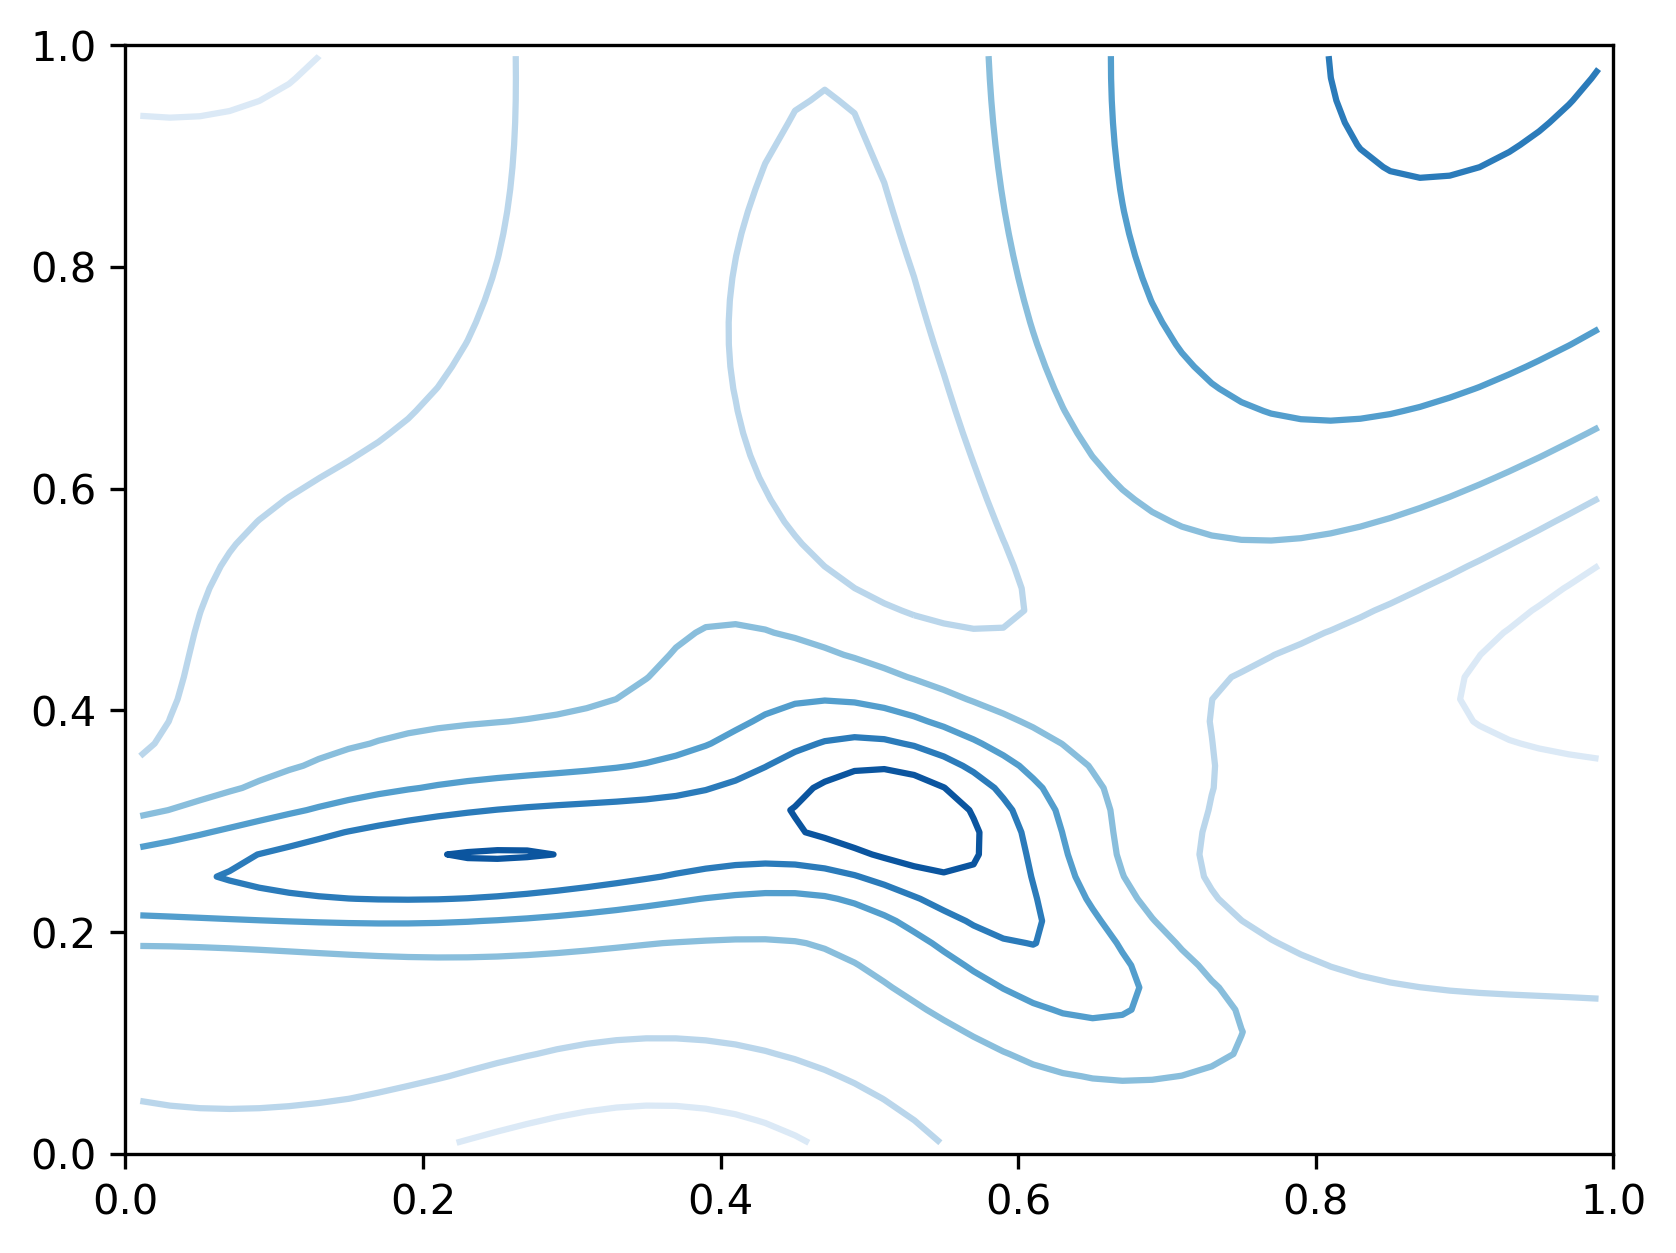

In [239]:
fig , ax = plt.subplots(1,1, dpi=300)
ax.set_xlim(0,1)         
ax.set_ylim(0,1)

n_grid = 50

XX = s_t[:,0].reshape(n_grid,n_grid)    # in DS, meshgrid is flatten
YY = s_t[:,1].reshape(n_grid,n_grid)

Z_ub = u_pred_immpute[2].reshape(n_grid, n_grid)
ax.contour(XX,YY, Z_ub, cmap='Blues')

In [237]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

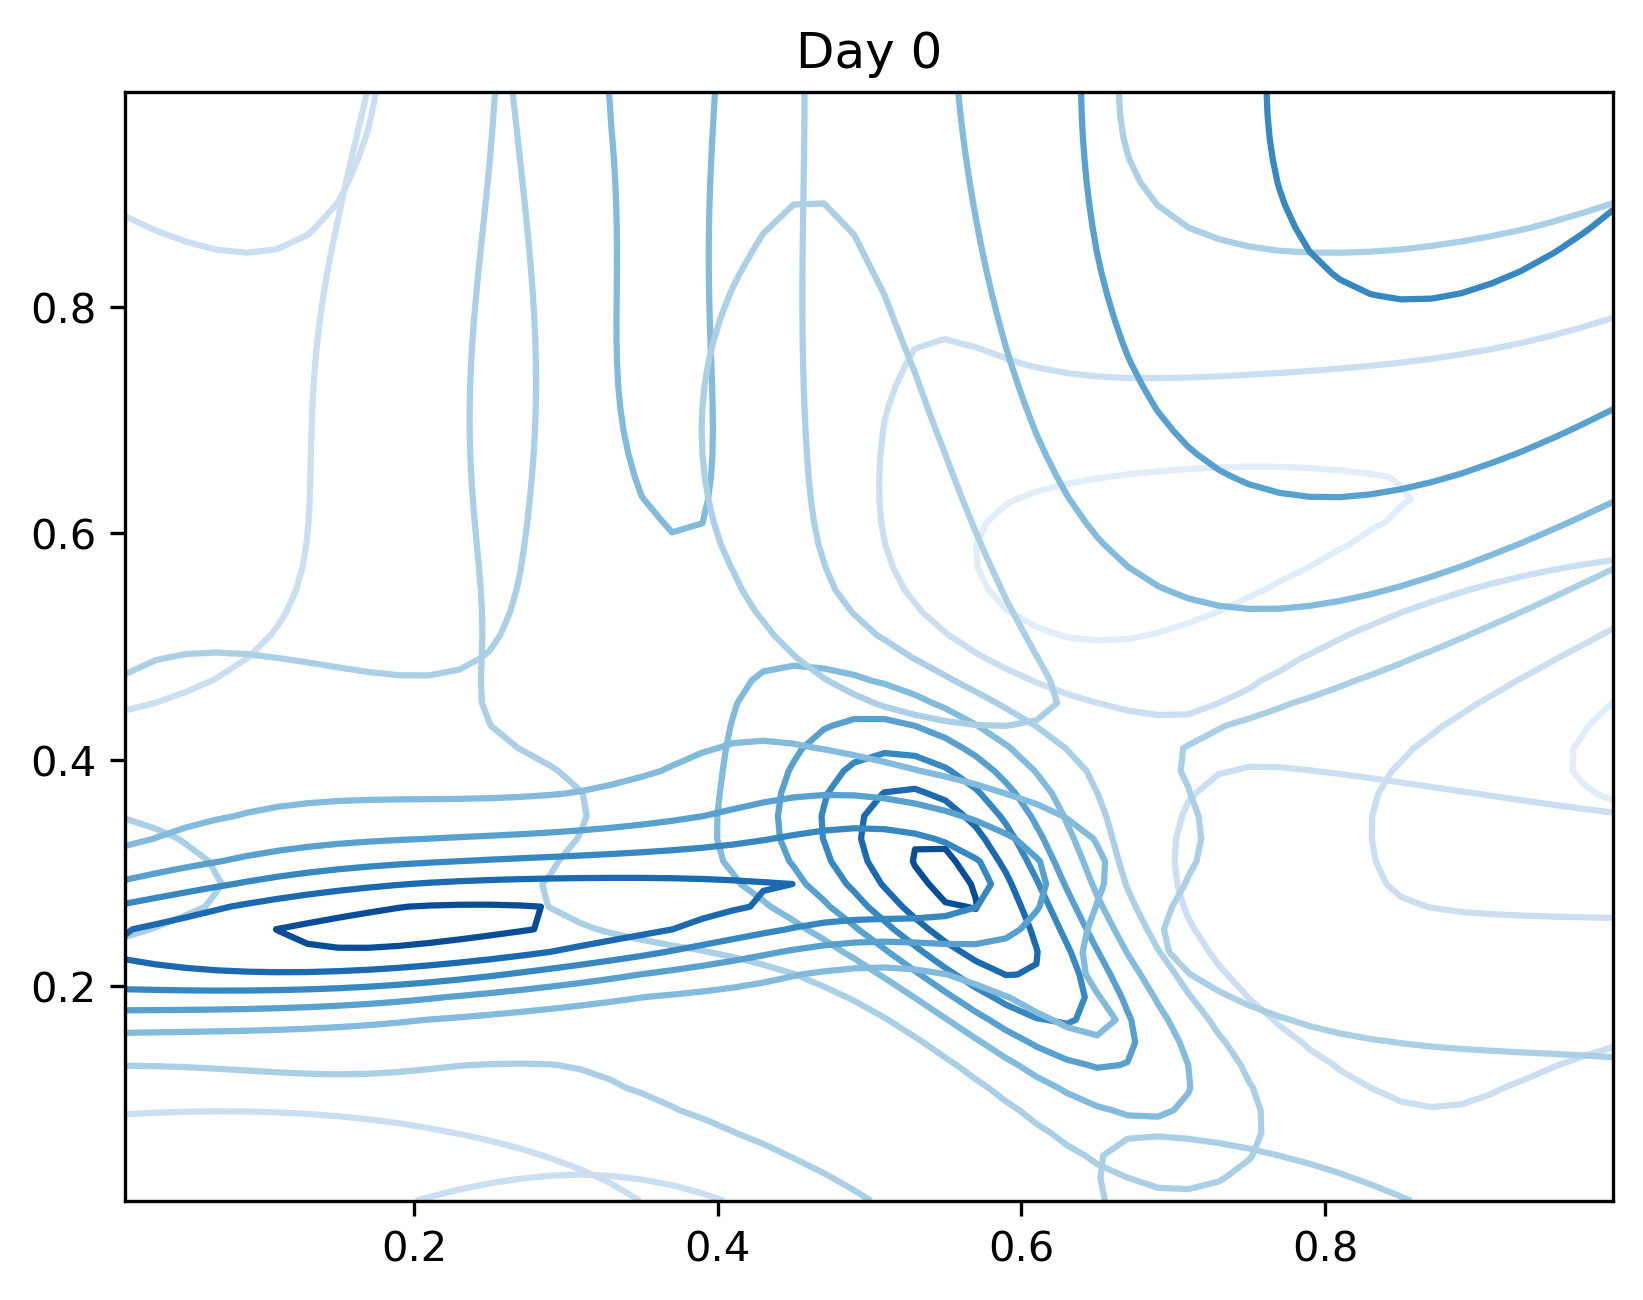

In [250]:
 
fig , ax = plt.subplots(1,1, dpi=300)
ax.set_xlim(0,1)         
ax.set_ylim(0,1)

n_grid = 50

XX = s_t[:,0].reshape(n_grid,n_grid)    # in DS, meshgrid is flatten
YY = s_t[:,1].reshape(n_grid,n_grid)

def init():
    Z_ub = u_pred_immpute[0].reshape(n_grid, n_grid)
    ax.contour(XX,YY, Z_ub, cmap='Blues')
    ax.set_title("Day 0")

def run(data):
    if data>0:
        ax.clear()   
        t = np.arange(3,50)[data]
        Z_ub = u_pred_immpute[data].reshape(n_grid, n_grid)
        ax.contour(XX,YY, Z_ub, cmap='Blues')
        ax.set_title("Day %d"%t)
    else:
        pass

ani = animation.FuncAnimation(fig, run, frames=47, interval=10, init_func=init)  # 製作動畫
ani.save('Explore_Notebook/density_change.gif', fps=5, writer='pillow') 